# Exercise 2: Statistical Visualization

---

This exercise focuses on data visualization using matplotlib and seaborn. It covers the M3-2: Statistical Visualization learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### A. Fundamentals of plotting
---


1. Explain the difference between a figure and an axes in matplotlib. (1-2 sentences)


- Figure as drawing frame (big box), but the axes it represent the same drawing or the smaller box. 

2. Name the three figure-level functions in seaborn.

- Relational plots: relationship between numerical variables.
- Distribution plots: display the distribution of data.
- Categoricale plot: display categorical data.


3. Briefly explain the difference between a Histogram and a Barplot. Which one is used to show the distribution of numerical data, and which is used for categorical data?

- Barplot: represent cthe ategorical data, Compares discrete groups.
- Histogeam: represent the numerical data, Shows how values ​​are distributed by dividing them into time intervals or groups called "bins".


### B. Subplots and Grids
---


1. Using a seaborn figure-level function (like sns.relplot or sns.displot), create subplots using the col and row parameters. For example, plot flipper_length_mm vs body_mass_g across columns for sex and rows for island.


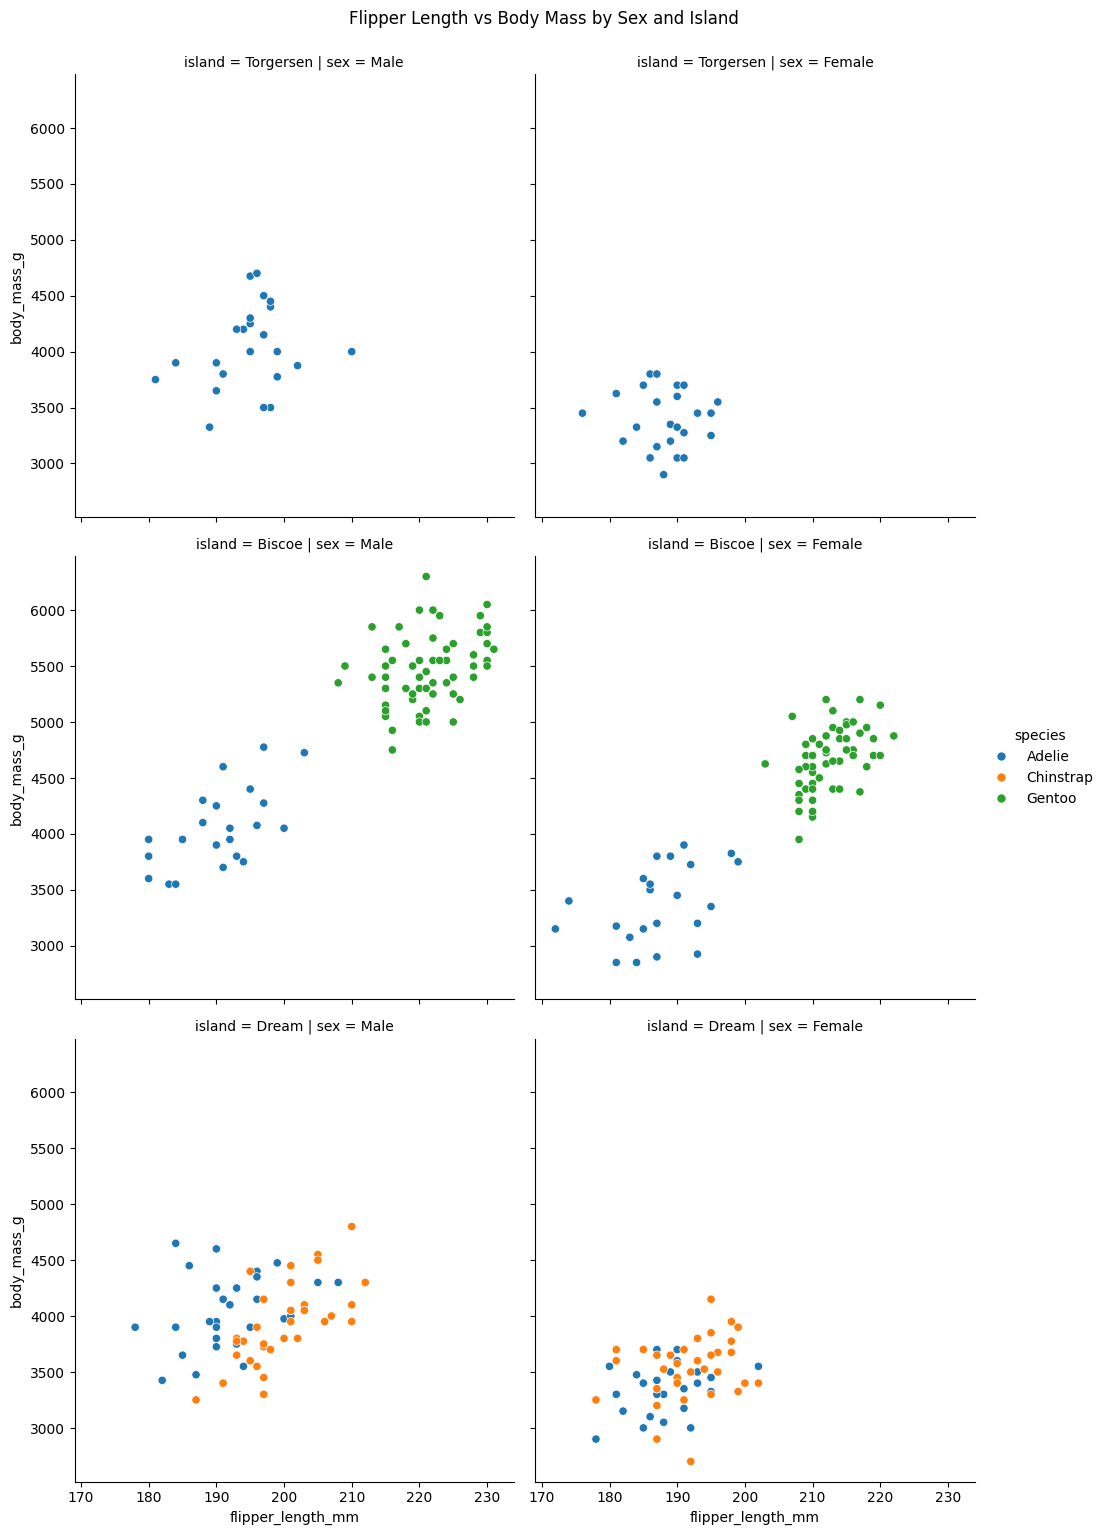

In [5]:
df.dropna()
g = sns.relplot(
    data=df, 
    x="flipper_length_mm", 
    y="body_mass_g", 
    hue="species", 
    col="sex", 
    row="island"
)

# إضافة عنوان للشبكة ككل
g.fig.suptitle("Flipper Length vs Body Mass by Sex and Island", y=1.02)
plt.show()

2. Using axes-level functions, create a figure with subplots (e.g., 1 row and 2 columns) using plt.subplots. - Plot a scatterplot of bill_length_mm vs bill_depth_mm on the first axes (ax1). - Plot a boxplot (or another axes-level plot of your choice) of bill_length_mm by species on the second axes (ax2). - Make sure to use sharey=True (or sharex=True) where appropriate so the subplots are linked on the shared dimension.

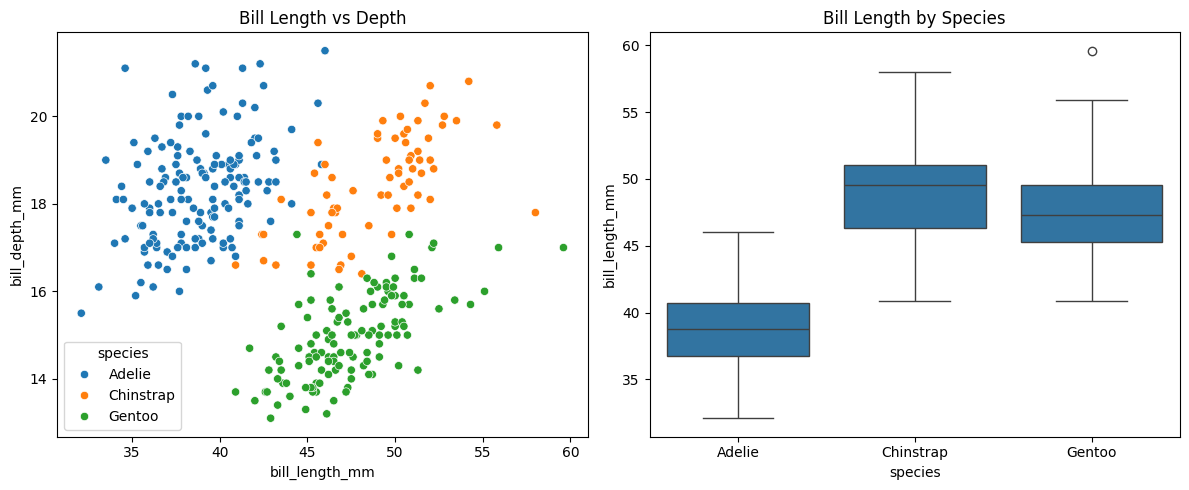

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df, 
    x="bill_length_mm", 
    y="bill_depth_mm", 
    hue="species", 
    ax=ax1
)
ax1.set_title("Bill Length vs Depth")

sns.boxplot(
    data=df, 
    x="species", 
    y="bill_length_mm", 
    ax=ax2
)
ax2.set_title("Bill Length by Species")

plt.tight_layout()
plt.show()

### C. Visualizing Distributions
---

1. Write code to show a box plot of flipper_length_mm separated by species.

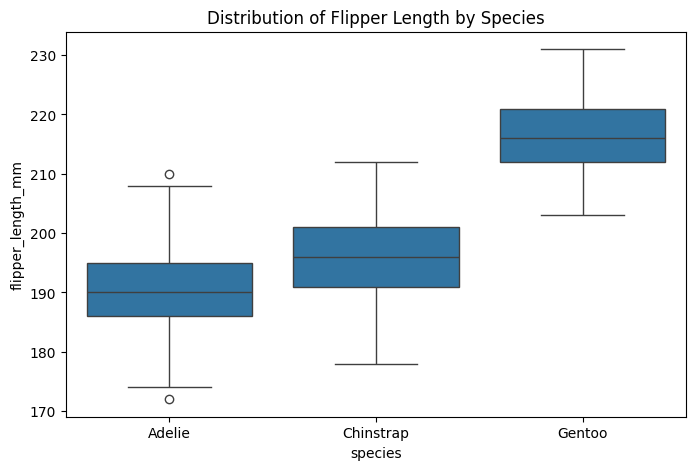

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="species", y="flipper_length_mm")
plt.title("Distribution of Flipper Length by Species")
plt.show()

2. Show two distributions on the same figure axes: plot the distribution of body_mass_g grouped by sex (e.g., using sns.kdeplot, or sns.histplot with overlapping transparent bins).


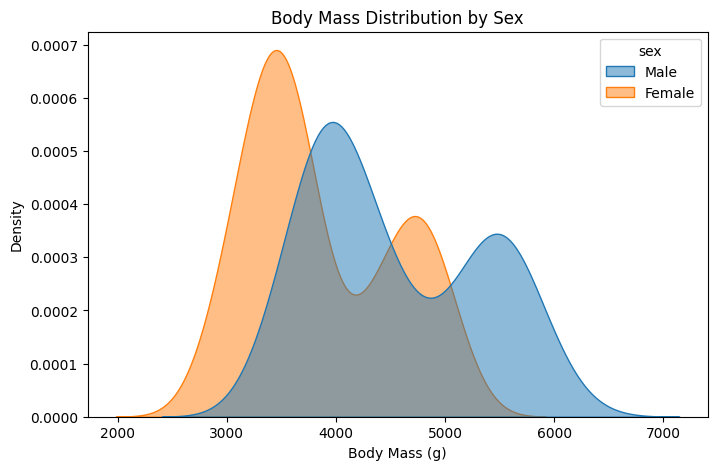

In [8]:
plt.figure(figsize=(8, 5))
#(KDE)
sns.kdeplot(data=df, x="body_mass_g", hue="sex", fill=True, common_norm=False, alpha=0.5)
plt.title("Body Mass Distribution by Sex")
plt.xlabel("Body Mass (g)")
plt.show()

3. Plot the Empirical Cumulative Distribution Function (ECDF) for body_mass_g, split by species. Briefly interpret what the plot tells you about how the species compare in weight.

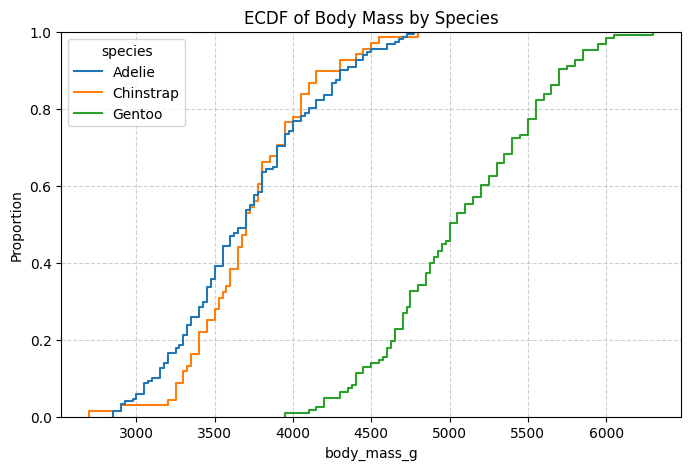

In [9]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x="body_mass_g", hue="species")
plt.title("ECDF of Body Mass by Species")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


4. Plot a bi-variate histogram using sns.histplot showing bill_length_mm on the x-axis and bill_depth_mm on the y-axis. What does the intensity mapping (the color blocks) represent?


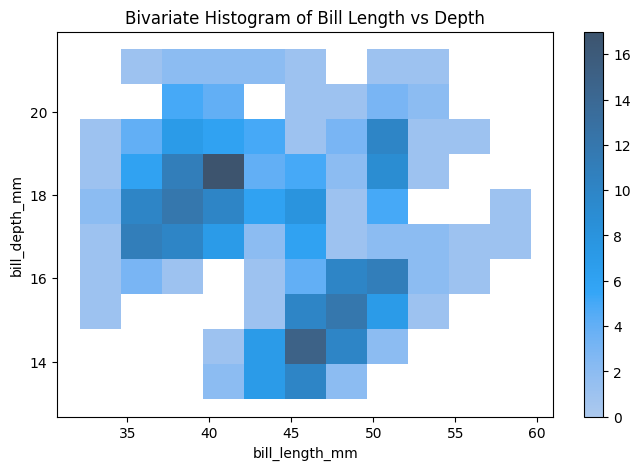

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="bill_length_mm", y="bill_depth_mm", cbar=True)
plt.title("Bivariate Histogram of Bill Length vs Depth")
plt.show()

### D. Categorical Data
---


1. Visualize numerical vs categorical relationships using sns.catplot(). Plot bill_depth_mm across different islands. Experiment with different categorical plot kinds (e.g., kind='violin' or kind='swarm').

/tmp/ipykernel_153322/1445697468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


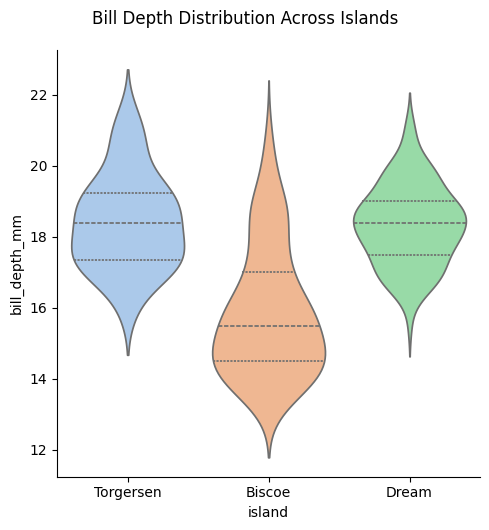

In [ ]:
df.dropna()
g = sns.catplot(
    data=df, 
    x="island", 
    y="bill_depth_mm", 
    kind="violin", # or "swaem" if it's smaill
    palette="pastel",
    inner="quart" 
)

g.fig.suptitle("Bill Depth Distribution Across Islands", y=1.05)
plt.show()

2. Visualize multiple categorical variables in one plot. Show a count of penguins by island, and further separate the counts by species (using the hue parameter in a count plot or a similar approach).

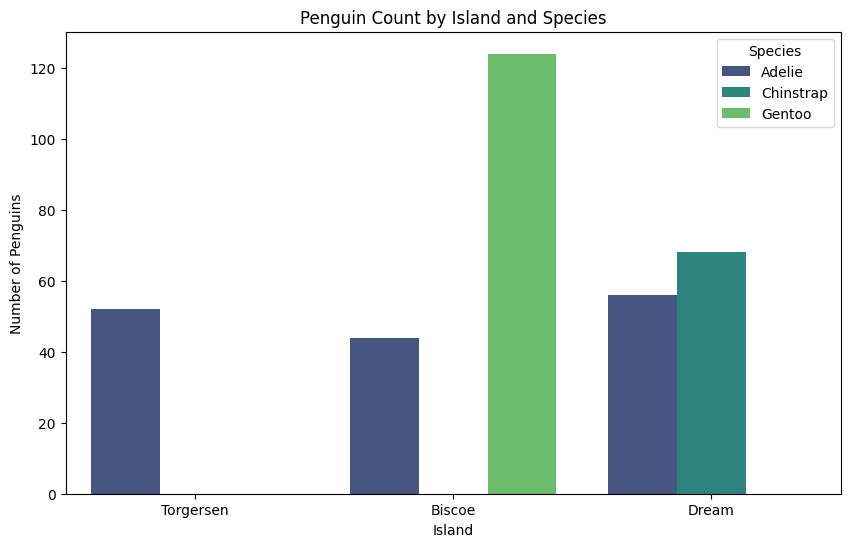

In [12]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df, 
    x="island", 
    hue="species", 
    palette="viridis"
)

plt.title("Penguin Count by Island and Species")
plt.xlabel("Island")
plt.ylabel("Number of Penguins")
plt.legend(title="Species", loc='upper right')
plt.show()

- note:

Biscoe Island: This is the only Gentoo species found on this island.
Adelie: This is the true "explorer" species, found on all three islands.
Dream Island: This is the only place you will find Chinstrap.

### E. Relational Plots and Aesthetics
---


1. Relate two numerical variables using a simple scatter plot: plot bill_length_mm vs flipper_length_mm.

2. Enhance the scatter plot from the previous step by using different colors (hue), markers (style), and sizes (size) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.